> **Open in Google Colab.** The next cell installs `coptpy`. The bundled free license is size-limited but covers this case. Then run *Runtime > Run all*.


In [ ]:
# COPT Python API
%pip install -q coptpy


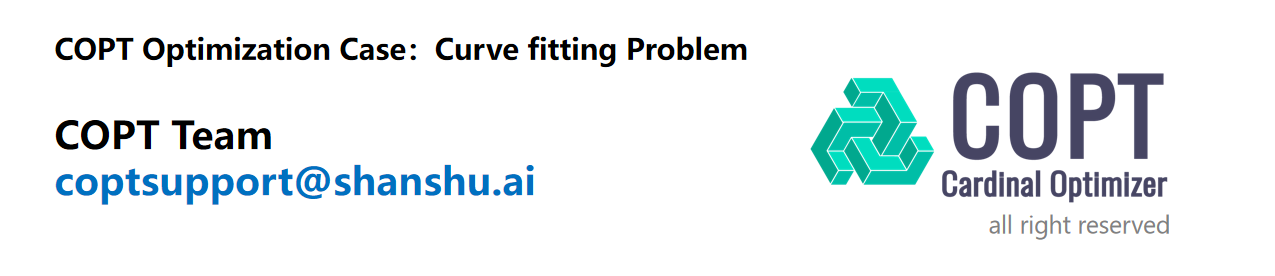

# Curve fitting Problem Code Implementation

## Steps to Model and Solve Curve fitting Problem Using COPT

1. **Import COPT-Python API** `coptpy`

2. **Add Model Data**
    - Import the coordinate of points

3. **Create the COPT Environment and COPT Model**

4. **Add three core components of COPT Model**
    - **Add Decision Variables**：
        - The parameters of the final model
    - **Set Objective Function**：Minimize the loss function
    - **Add Constraints**：
        - No constraint

5. **Solve**

6. View and interpret the **results**


## Import COPT-Python API

In [4]:
import coptpy as cp
from coptpy import COPT

import matplotlib.pyplot as plt
import numpy as np
import random

## Add Model Data

In [6]:
# Set the random number seed to facilitate reproducibility
random.seed(42)
np.random.seed(42)

# Set the model degree
model_degree = 4

# Set the highest matching degree
max_degree = 9

# Generate a random function
coeff = [(random.random() - 0.5) * (i + 2) * (i + 3) * (i + 4) for i in range(model_degree + 1)]
print(coeff)

# Set the number of points
num_points = 20
points_x = [random.random() * 10 - 5 for _ in range(num_points)]
points_y = []
for i in range(num_points):
    points_y.append(coeff[0])
    for j in range(model_degree):
        points_y[-1] *=  points_x[i]
        points_y[-1] += coeff[j + 1]
    points_y[-1] += np.random.normal(0, 750)

print(points_y)


[3.34624316298921, -28.499354686639986, -26.99648179570569, -58.125744988747215, 79.45432795910817]
[140.38083986848352, -1594.891025355613, 3327.357652911409, 1265.4613637356363, 4178.680875280102, 698.1810174524855, 1260.6693654263836, 5031.388241375517, 711.2788403830416, 259.52941407666714, -302.13447119057435, 508.7223752728727, 169.38097500341297, -2331.4339101699256, 3825.216046986452, -1294.9456618869076, -1071.4406294387893, 477.0794728909642, 915.1029371238966, -3071.490197479746]


## Create the COPT Environment and COPT Model

In [8]:
env = cp.Envr()
model = env.createModel()

Cardinal Optimizer v8.0.5. Build date May 30 2026
Copyright Cardinal Operations 2026. All Rights Reserved



## Add three core components of COPT Model

### Add Decision Variables

In [10]:
A = model.addVars(max_degree + 1, lb=-COPT.INFINITY, nameprefix='A')

### Set Objective Function
Minimize the loss function
$$
    \min \quad \sum_{i = 1}^{\text{num}_\text{points}}(y_i - \sum_{j = 0}^{\text{max}_\text{degree}}a_j\cdot x_i^j)^2
$$


In [12]:
predict_num = []
for i in range(num_points):
    predict_num.append(A[0])
    for j in range(max_degree):
        predict_num[-1] *= points_x[i]
        predict_num[-1] += A[j + 1]

model.setObjective(cp.quicksum((points_y[i] - predict_num[i]) * (points_y[i] - predict_num[i]) for i in range(num_points)), sense=COPT.MINIMIZE)

### Add Constraints
This problem is a non-constraints problem

## Solve

In [15]:
# Turn off log display
model.setParam(COPT.Param.Logging, False)

model.solve()

## Retrieve Results


9-degree model related information
Minimum error is 2964402.11
Constant term: 676.67
1-degree term coefficient: -419.83
2-degree term coefficient: 9.13
3-degree term coefficient: 50.07
4-degree term coefficient: -64.23
5-degree term coefficient: -8.89
6-degree term coefficient: 6.94
7-degree term coefficient: 0.53
8-degree term coefficient: -0.19
9-degree term coefficient: -0.01

8-degree model related information
Minimum error is 2996578.26
Constant term: 686.36
1-degree term coefficient: -321.15
2-degree term coefficient: -20.72
3-degree term coefficient: -10.05
4-degree term coefficient: -55.37
5-degree term coefficient: 1.08
6-degree term coefficient: 6.15
7-degree term coefficient: -0.09
8-degree term coefficient: -0.16

7-degree model related information
Minimum error is 4029004.97
Constant term: 973.75
1-degree term coefficient: -419.39
2-degree term coefficient: -449.25
3-degree term coefficient: 63.29
4-degree term coefficient: 42.19
5-degree term coefficient: -7.8
6-degree t

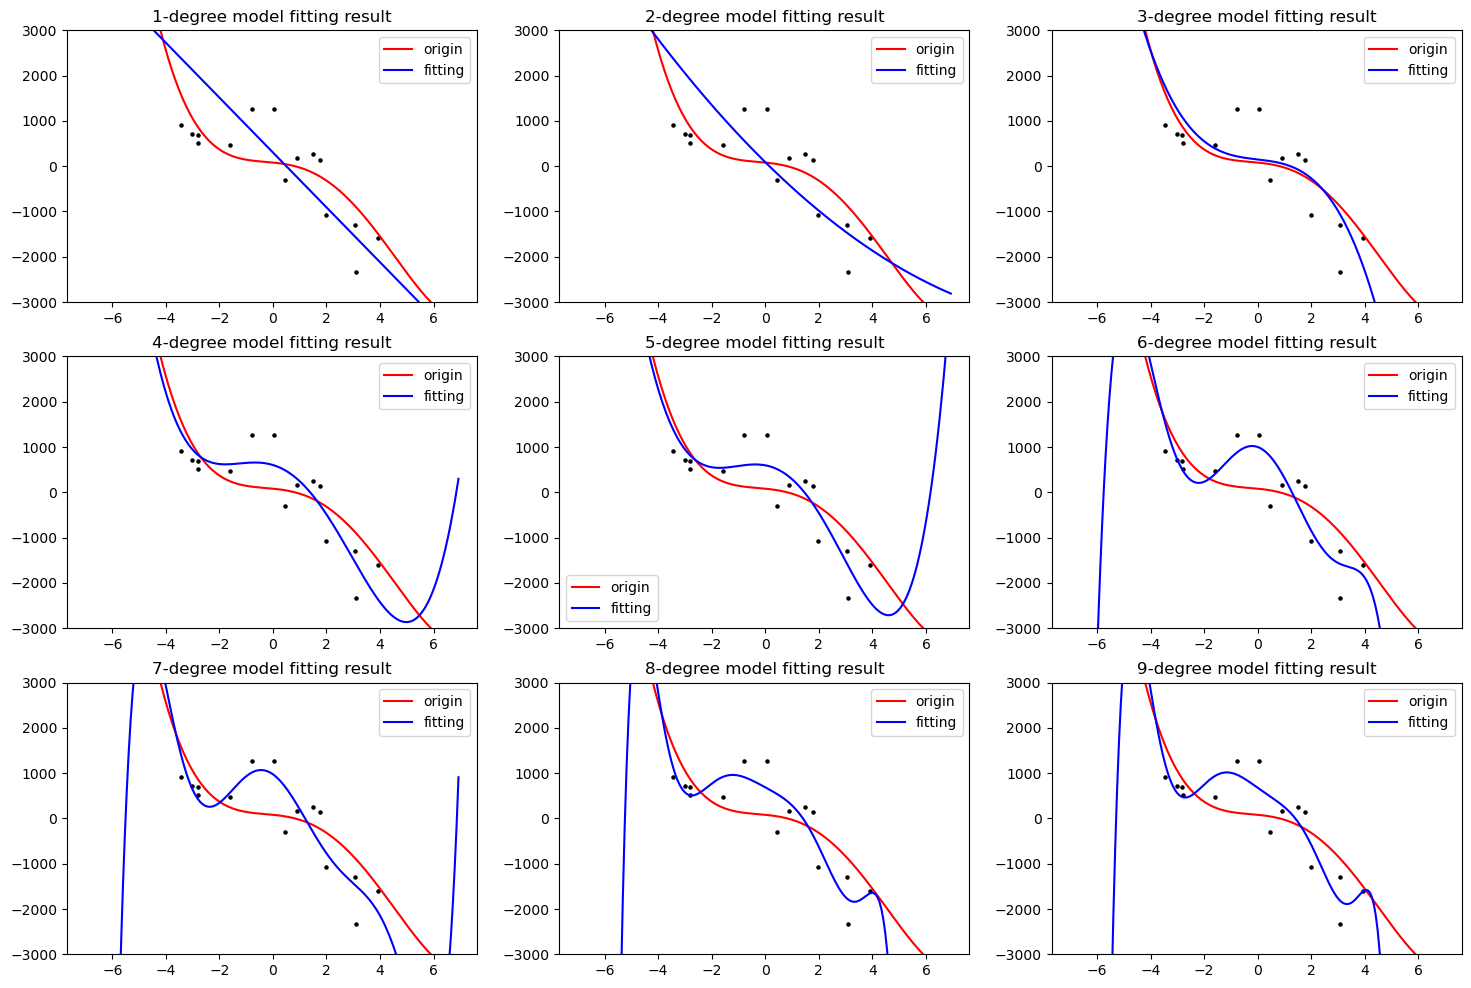

In [17]:
# Set subgraph
fig, axs = plt.subplots(3, 3, figsize=(18, 12))

# Repeat nine times to solve nine models fitting functions from degree 1 to degree 9
for i in range(9, 0, -1):
    # The ninth-degree model does not need to add constraints
    if i < 9:
        model.addConstr(A[8 - i] == 0)
    model.solve()
    print(f'\n{i}-degree model related information')
    if model.status == COPT.OPTIMAL:
        print(f'Minimum error is {round(model.objval, 2)}')
        variables = model.getVars()
        print(f'Constant term: {round(variables[9].x, 2)}')
        for j in range(1, i + 1):
            print(f'{j}-degree term coefficient: {round(variables[9 - j].x, 2)}')
        # Plot subplot
        sub = axs[int((i - 1) / 3), (i - 1) % 3]
        # Plot points
        sub.scatter(points_x, points_y, c='black', s=5)
        # Plot curve
        max_x = 7
        min_x = -7
        num_points_cal = 200
        x_origin = [min_x + k * (max_x - min_x) / num_points_cal for k in range(num_points_cal)]
        y_origin = []
        for k in range(num_points_cal):
            y_origin.append(coeff[0])
            for j in range(model_degree):
                y_origin[-1] *= x_origin[k]
                y_origin[-1] += coeff[j + 1]
        sub.plot(x_origin, y_origin, c='red', label='origin')
        x_cal = [min_x + k * (max_x - min_x) / num_points_cal for k in range(num_points_cal)]
        y_cal = []
        for k in range(num_points_cal):
            y_cal.append(A[0].x)
            for j in range(max_degree):
                y_cal[-1] *= x_cal[k]
                y_cal[-1] += A[j + 1].x
        sub.plot(x_cal, y_cal, c='blue', label='fitting')
        sub.set_title(f'{i}-degree model fitting result')
        sub.legend()
        sub.set_ylim(-3000, 3000)
    else:
        print('No optimal solution found.')
plt.show()

> It can be observed that higher-degree models exhibit more severe overfitting.

# Case Expansion
## Ridge regression(L2 regularization)
The objective function change to teh following formula:
$$
    \min \quad \sum_{i = 1}^{\text{num}_\text{points}}(y_i - \sum_{j = 0}^{\text{max}_\text{degree}}a_j\cdot x_i^j)^2 + \sum_{j = 0}^{\text{max}_\text{degree}}a_j^2
$$


9-degree model related information
Minimum error is 7365385.56
Constant term: 1.05
1-degree term coefficient: -1.49
2-degree term coefficient: -2.39
3-degree term coefficient: -4.18
4-degree term coefficient: -16.06
5-degree term coefficient: -5.38
6-degree term coefficient: 1.94
7-degree term coefficient: 0.24
8-degree term coefficient: -0.05
9-degree term coefficient: -0.0

8-degree model related information
Minimum error is 7386176.63
Constant term: 1.06
1-degree term coefficient: -1.67
2-degree term coefficient: -2.23
3-degree term coefficient: -4.9
4-degree term coefficient: -14.97
5-degree term coefficient: -4.45
6-degree term coefficient: 1.77
7-degree term coefficient: 0.14
8-degree term coefficient: -0.05

7-degree model related information
Minimum error is 8172365.92
Constant term: 0.83
1-degree term coefficient: -1.15
2-degree term coefficient: -2.26
3-degree term coefficient: -2.01
4-degree term coefficient: -3.52
5-degree term coefficient: -5.48
6-degree term coefficient:

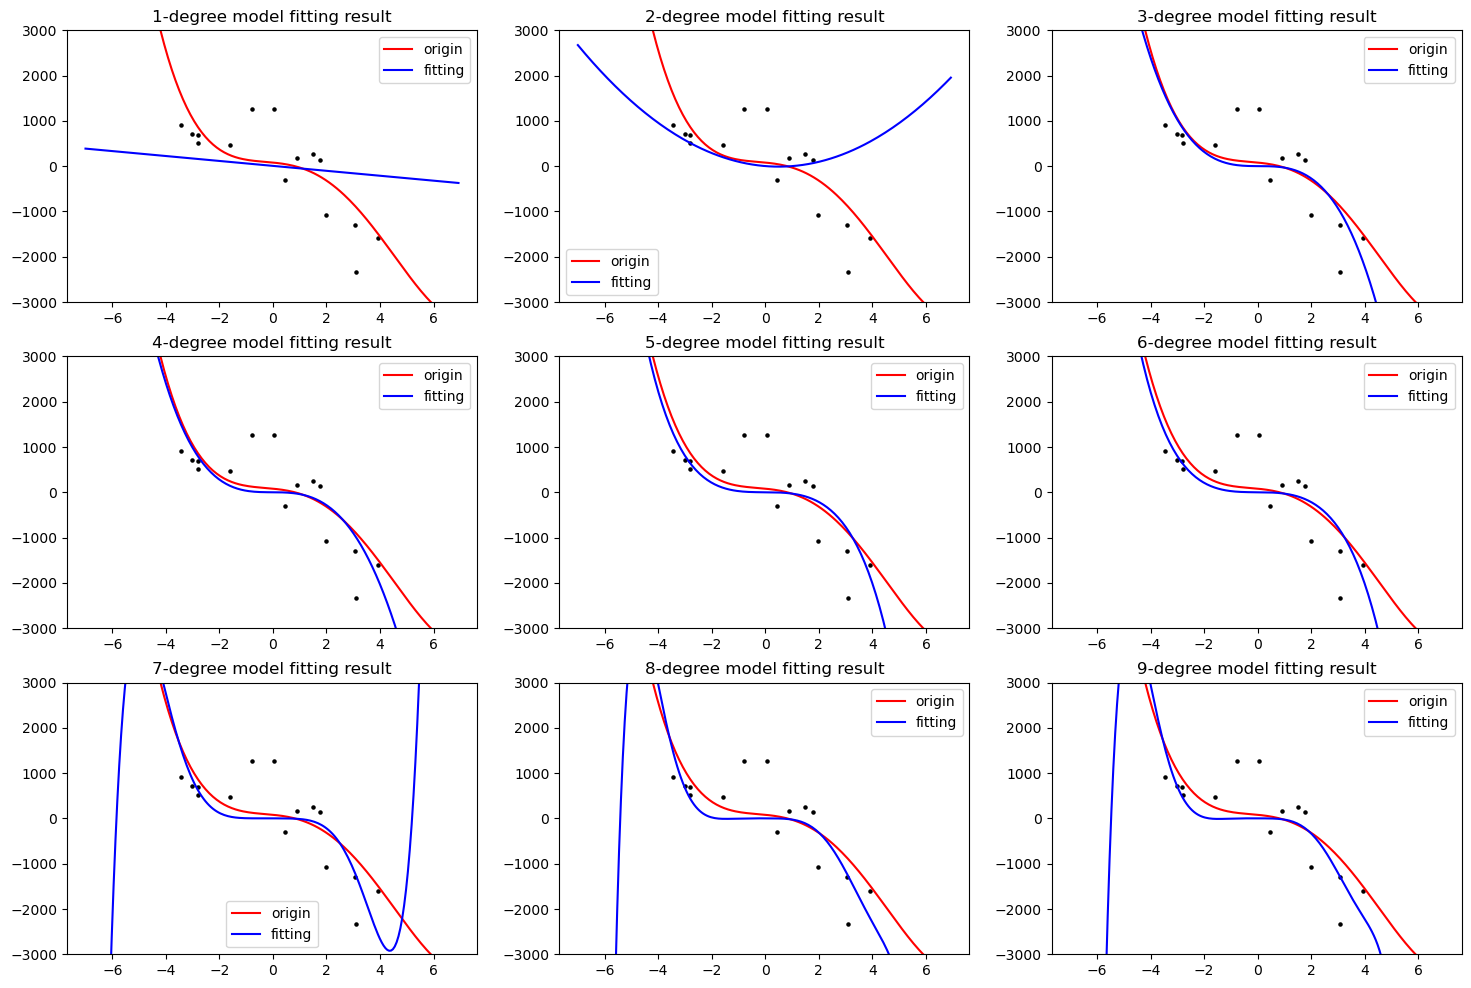

In [20]:
# Clear the constraints
model.remove(model.getConstrs())

# Set lambda to control the strength
lbd = 2000

# Change the constraints and add regularization term
model.setObjective(cp.quicksum((points_y[i] - predict_num[i]) * (points_y[i] - predict_num[i]) for i in range(num_points))
                   + cp.quicksum(A[i] * A[i] for i in range(10)) * lbd, sense=COPT.MINIMIZE)

# Set subgraph
fig, axs = plt.subplots(3, 3, figsize=(18, 12))

# Repeat nine times to solve nine models fitting functions from degree 1 to degree 9
for i in range(9, 0, -1):
    # The ninth-degree model does not need to add constraints
    if i < 9:
        model.addConstr(A[8 - i] == 0)
    model.solve()
    print(f'\n{i}-degree model related information')
    if model.status == COPT.OPTIMAL:
        print(f'Minimum error is {round(model.objval, 2)}')
        variables = model.getVars()
        print(f'Constant term: {round(variables[9].x, 2)}')
        for j in range(1, i + 1):
            print(f'{j}-degree term coefficient: {round(variables[9 - j].x, 2)}')
        # Plot subplot
        sub = axs[int((i - 1) / 3), (i - 1) % 3]
        # Plot points
        sub.scatter(points_x, points_y, c='black', s=5)
        # Plot curve
        max_x = 7
        min_x = -7
        num_points_cal = 200
        x_origin = [min_x + k * (max_x - min_x) / num_points_cal for k in range(num_points_cal)]
        y_origin = []
        for k in range(num_points_cal):
            y_origin.append(coeff[0])
            for j in range(model_degree):
                y_origin[-1] *= x_origin[k]
                y_origin[-1] += coeff[j + 1]
        sub.plot(x_origin, y_origin, c='red', label='origin')
        x_cal = [min_x + k * (max_x - min_x) / num_points_cal for k in range(num_points_cal)]
        y_cal = []
        for k in range(num_points_cal):
            y_cal.append(A[0].x)
            for j in range(max_degree):
                y_cal[-1] *= x_cal[k]
                y_cal[-1] += A[j + 1].x
        sub.plot(x_cal, y_cal, c='blue', label='fitting')
        sub.set_title(f'{i}-degree model fitting result')
        sub.legend()
        sub.set_ylim(-3000, 3000)
    else:
        print('No optimal solution found.')
plt.show()

## Lasso Regression(L1 regularization)
The objective function change to teh following formula:
$$
    \min \quad \sum_{i = 1}^{\text{num}_\text{points}}(y_i - \sum_{j = 0}^{\text{max}_\text{degree}}a_j\cdot x_i^j)^2 + \sum_{j = 0}^{\text{max}_\text{degree}}|a_j|
$$
Considering the absolute value. we add auxilary variable $b$ and constraints:
$$
    b_j \geq a_j, \, \forall \, j \\
    b_j \geq -a_j, \, \forall \, j
$$
where $b_j=|a_j|, \, \forall \, j$ will be automatically established due to the minimization sense.


9-degree model related information
Minimum error is 3619349.82
Constant term: 617.33
1-degree term coefficient: -93.18
2-degree term coefficient: 0.0
3-degree term coefficient: -62.32
4-degree term coefficient: -59.58
5-degree term coefficient: 4.29
6-degree term coefficient: 6.53
7-degree term coefficient: -0.11
8-degree term coefficient: -0.18
9-degree term coefficient: -0.0

8-degree model related information
Minimum error is 3619933.04
Constant term: 615.2
1-degree term coefficient: -80.49
2-degree term coefficient: -0.0
3-degree term coefficient: -70.23
4-degree term coefficient: -59.18
5-degree term coefficient: 5.59
6-degree term coefficient: 6.47
7-degree term coefficient: -0.19
8-degree term coefficient: -0.17

7-degree model related information
Minimum error is 5506887.8
Constant term: 824.0
1-degree term coefficient: -150.34
2-degree term coefficient: -389.89
3-degree term coefficient: 0.0
4-degree term coefficient: 36.57
5-degree term coefficient: -3.43
6-degree term coeff

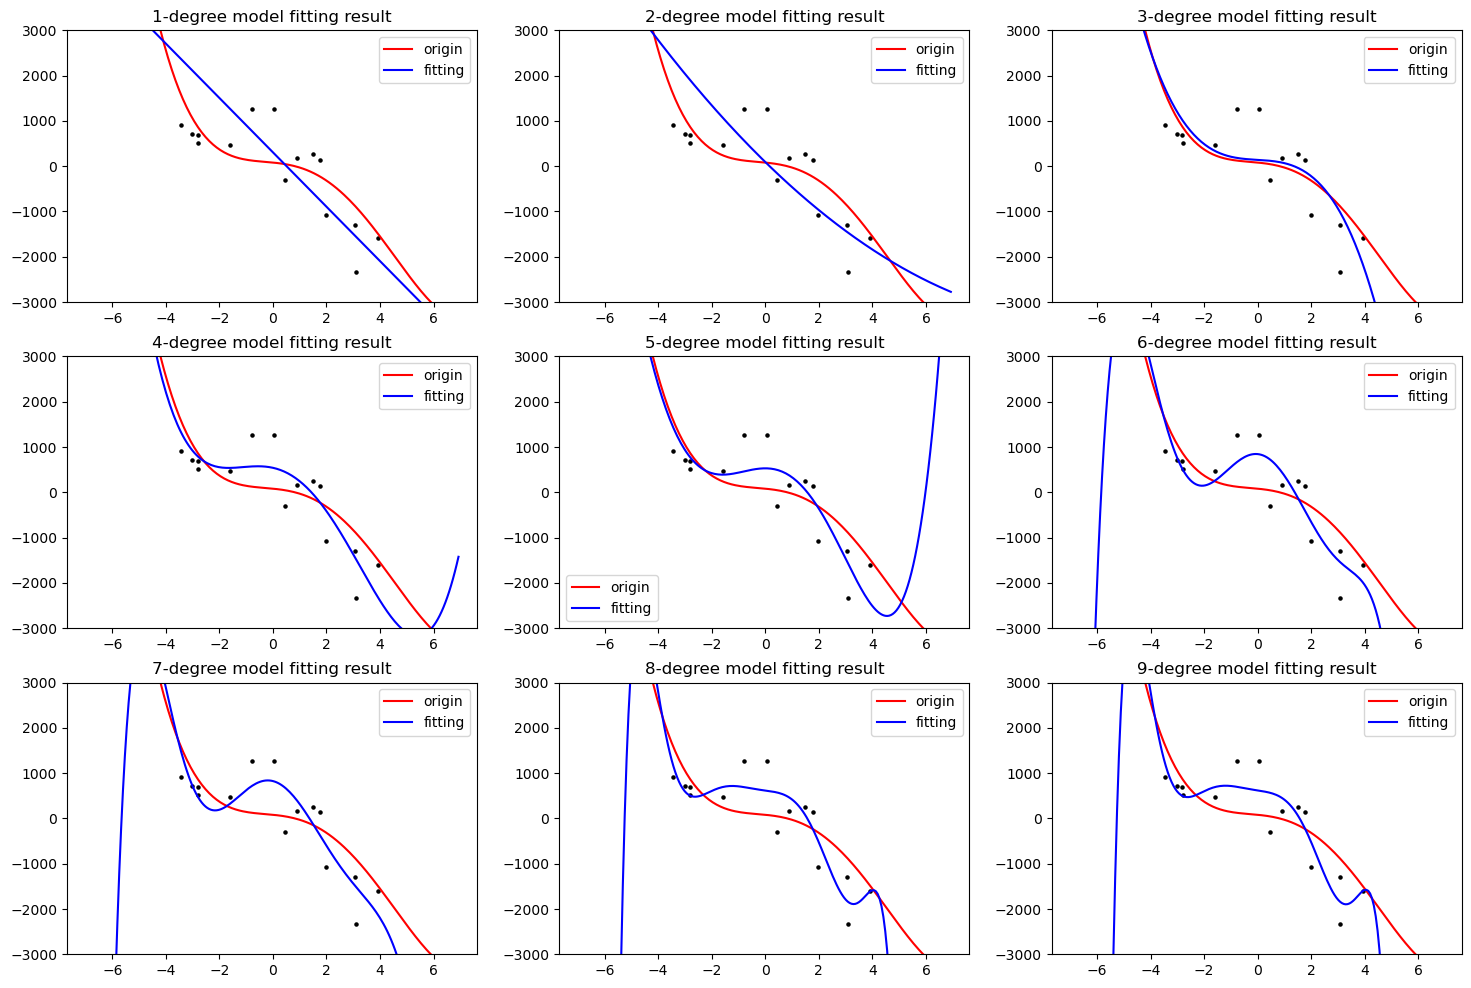

In [22]:
# Clear the constraints
model.remove(model.getConstrs())

# Add auxilary variables to linearize the absolute value
B = model.addVars(max_degree + 1, lb=-COPT.INFINITY, nameprefix='B')
model.addConstrs(B[i] >= A[i] for i in range(max_degree))
model.addConstrs(B[i] >= -A[i] for i in range(max_degree))

# Change the constraints and add regularization term
model.setObjective(cp.quicksum((points_y[i] - predict_num[i]) * (points_y[i] - predict_num[i]) for i in range(num_points))
                   + cp.quicksum(B[i] for i in range(10)) * lbd, sense=COPT.MINIMIZE)

# Set subgraph
fig, axs = plt.subplots(3, 3, figsize=(18, 12))

# Repeat nine times to solve nine models fitting functions from degree 1 to degree 9
for i in range(9, 0, -1):
    # The ninth-degree model does not need to add constraints
    if i < 9:
        model.addConstr(A[8 - i] == 0)
    model.solve()
    print(f'\n{i}-degree model related information')
    if model.status == COPT.OPTIMAL:
        print(f'Minimum error is {round(model.objval, 2)}')
        variables = model.getVars()
        print(f'Constant term: {round(variables[9].x, 2)}')
        for j in range(1, i + 1):
            print(f'{j}-degree term coefficient: {round(variables[9 - j].x, 2)}')
        # Plot subplot
        sub = axs[int((i - 1) / 3), (i - 1) % 3]
        # Plot points
        sub.scatter(points_x, points_y, c='black', s=5)
        # Plot curve
        max_x = 7
        min_x = -7
        num_points_cal = 200
        x_origin = [min_x + k * (max_x - min_x) / num_points_cal for k in range(num_points_cal)]
        y_origin = []
        for k in range(num_points_cal):
            y_origin.append(coeff[0])
            for j in range(model_degree):
                y_origin[-1] *= x_origin[k]
                y_origin[-1] += coeff[j + 1]
        sub.plot(x_origin, y_origin, c='red', label='origin')
        x_cal = [min_x + k * (max_x - min_x) / num_points_cal for k in range(num_points_cal)]
        y_cal = []
        for k in range(num_points_cal):
            y_cal.append(A[0].x)
            for j in range(max_degree):
                y_cal[-1] *= x_cal[k]
                y_cal[-1] += A[j + 1].x
        sub.plot(x_cal, y_cal, c='blue', label='fitting')
        sub.set_title(f'{i}-degree model fitting result')
        sub.legend()
        sub.set_ylim(-3000, 3000)
    else:
        print('No optimal solution found.')
plt.show()